# Adaptive Superlet time-frequency power

## tl;dr

- EEG is resampled to 125 Hz and transformed on the exact 2-40 Hz grid.
- Fractional adaptive order increases linearly from 1 to 10; the base wavelet has `c_1=3` cycles.
- Stored features are `abs(coefficients) ** 2`, with edge-contaminated samples removed before centered 32-sample averaging (0.256 s).
- A synthetic 20/24 Hz pair validates close-frequency separation before one canonical `exec` and `patt` block are inspected.


## Context, provenance, and scope

This notebook validates spectral preprocessing checkpoint 6. It demonstrates transform mechanics and artifact contracts; it does not compare recording families statistically and does not define an ML split.

The transform is a typed adaptation of Gregor Mönke's Python implementation in [tensionhead/Superlets](https://github.com/tensionhead/Superlets/blob/main/python/superlet.py), pinned in the module docstring to commit `20f6bfdf31b783b4d8254546effa8f27784118a2`. The upstream [reference repository](https://github.com/TransylvanianInstituteOfNeuroscience/Superlets) and copied [MIT license](../preprocessors/SUPERLET_LICENSE.txt) are recorded with the implementation. Algorithm reference: Moca et al. (2021), *Time-frequency super-resolution with superlets*, Nature Communications.

Superlet and Morlet values are wavelet power, whereas FFT/STFT values are PSD. Absolute amplitudes across these scaling families must not be compared directly.


In [1]:
import os
import sys
from pathlib import Path
from time import perf_counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-superlet")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find project root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocessors import (
    SuperletConfig,
    build_frequency_grid,
    compute_adaptive_order,
    compute_superlet_power,
    load_preprocessing_config,
    superlet_edge_samples,
)
from preprocessors.superlet import scale_from_period, superlet_support
from utils.datasets import SuperletDataset


config = load_preprocessing_config("superlet")
assert isinstance(config, SuperletConfig)
frequencies = build_frequency_grid(config)
orders = compute_adaptive_order(frequencies, config.order_min, config.order_max)
edge_samples = superlet_edge_samples(
    frequencies,
    sfreq=config.analysis_sfreq,
    order_min=config.order_min,
    order_max=config.order_max,
    c_1=config.c_1,
)

pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "analysis_sfreq_hz": config.analysis_sfreq,
        "frequency_range_hz": f"{config.f_min:g}-{config.f_max:g}",
        "frequency_step_hz": config.frequency_step,
        "adaptive_order_range": f"{config.order_min}-{config.order_max}",
        "base_cycles_c1": config.c_1,
        "edge_samples_per_side": edge_samples,
        "time_bin_samples": config.time_bin_samples,
        "time_step_seconds": config.time_bin_samples / config.analysis_sfreq,
        "output_dtype": config.dtype,
    },
    name="Superlet configuration",
)


project_root             /home/slauva/Projects/master-thesis-2024-2026/...
analysis_sfreq_hz                                                    125.0
frequency_range_hz                                                    2-40
frequency_step_hz                                                      1.0
adaptive_order_range                                                  1-10
base_cycles_c1                                                           3
edge_samples_per_side                                                  199
time_bin_samples                                                        32
time_step_seconds                                                    0.256
output_dtype                                                       float32
Name: Superlet configuration, dtype: object

## Fractional wavelet geometry

For a non-integer adaptive order, the transform includes the next integer-order wavelet with a fractional exponent. Edge trimming must therefore use the longest wavelet that actually contributes, not only the base wavelet at the lowest frequency. With the default grid, the limiting support occurs at 3 Hz, where order 1.237 includes part of the six-cycle wavelet.


In [2]:
geometry_rows = []
for frequency in (2.0, 3.0, 4.0, 10.0, 20.0, 40.0):
    index = int(np.searchsorted(frequencies, frequency))
    order = orders[index]
    contributing_cycles = config.c_1 * np.ceil(order)
    scale = float(scale_from_period(1.0 / frequency))
    support = superlet_support(
        scale,
        1.0 / config.analysis_sfreq,
        contributing_cycles,
    )
    geometry_rows.append(
        {
            "frequency_hz": frequency,
            "adaptive_order": order,
            "highest_contributing_cycles": int(contributing_cycles),
            "longest_support_samples": support.size,
            "support_duration_s": support.size / config.analysis_sfreq,
        }
    )

geometry = pd.DataFrame(geometry_rows).set_index("frequency_hz")
assert edge_samples == 199
assert geometry.loc[3.0, "longest_support_samples"] == 398
geometry


,adaptive_order,highest_contributing_cycles,longest_support_samples,support_duration_s
frequency_hz,,,,
2.0,1.000000,3,299,2.392
3.0,1.236842,6,398,3.184
4.0,1.473684,6,299,2.392
10.0,2.894737,9,180,1.440
20.0,5.263158,18,180,1.440
40.0,10.000000,30,150,1.200


## Synthetic validation

Two equal-amplitude stationary tones at 20 and 24 Hz test the frequency super-resolution claim without conflating it with burst timing. The validation requires local maxima at both generating frequencies and a lower midpoint at 22 Hz.


output_shape          (1, 39, 26)
runtime_seconds          0.026341
power_20_hz              0.209292
power_22_hz_valley       0.075375
power_24_hz              0.210841
finite                       True
non_negative                 True
Name: Synthetic validation, dtype: object

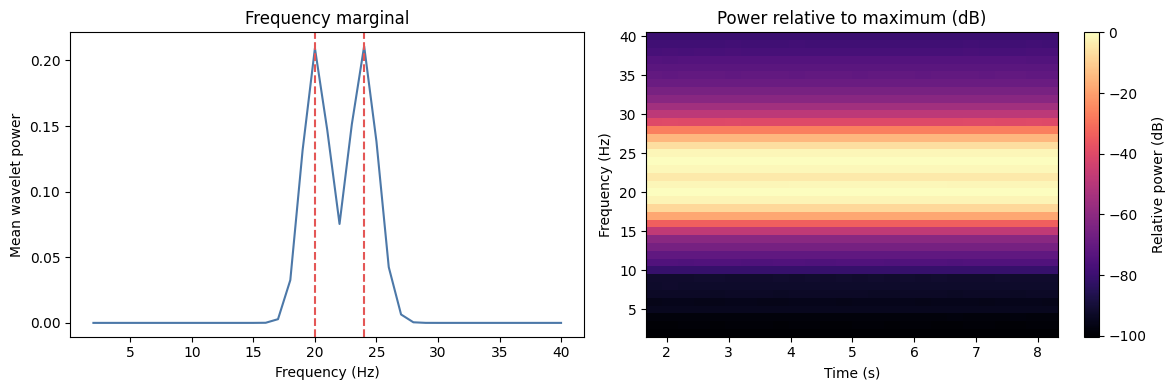

In [3]:
source_sfreq = 1_000.0
source_time = np.arange(10_000, dtype=np.float64) / source_sfreq
synthetic_eeg = (
    np.sin(2.0 * np.pi * 20.0 * source_time)
    + np.sin(2.0 * np.pi * 24.0 * source_time)
)[np.newaxis, :]

started = perf_counter()
synthetic_result = compute_superlet_power(
    synthetic_eeg,
    source_sfreq=source_sfreq,
    config=config,
)
synthetic_seconds = perf_counter() - started
frequency_marginal = synthetic_result.eeg_power[0].mean(axis=1)

def power_at(frequency: float) -> float:
    index = int(np.searchsorted(synthetic_result.frequencies, frequency))
    return float(frequency_marginal[index])


assert synthetic_result.eeg_power.shape == (1, 39, 26)
assert np.isfinite(synthetic_result.eeg_power).all()
assert np.all(synthetic_result.eeg_power >= 0)
assert power_at(20.0) > power_at(19.0)
assert power_at(20.0) > power_at(21.0)
assert power_at(24.0) > power_at(23.0)
assert power_at(24.0) > power_at(25.0)
assert power_at(22.0) < min(power_at(20.0), power_at(24.0))

validation = pd.Series(
    {
        "output_shape": synthetic_result.eeg_power.shape,
        "runtime_seconds": synthetic_seconds,
        "power_20_hz": power_at(20.0),
        "power_22_hz_valley": power_at(22.0),
        "power_24_hz": power_at(24.0),
        "finite": bool(np.isfinite(synthetic_result.eeg_power).all()),
        "non_negative": bool(np.all(synthetic_result.eeg_power >= 0)),
    },
    name="Synthetic validation",
)
display(validation)

display_power = 10.0 * np.log10(
    np.maximum(synthetic_result.eeg_power[0], np.finfo(np.float32).tiny)
)
display_power -= display_power.max()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(synthetic_result.frequencies, frequency_marginal, color="#4C78A8")
axes[0].axvline(20.0, color="#E45756", linestyle="--")
axes[0].axvline(24.0, color="#E45756", linestyle="--")
axes[0].set(xlabel="Frequency (Hz)", ylabel="Mean wavelet power", title="Frequency marginal")
mesh = axes[1].pcolormesh(
    synthetic_result.times,
    synthetic_result.frequencies,
    display_power,
    shading="auto",
    cmap="magma",
)
axes[1].set(xlabel="Time (s)", ylabel="Frequency (Hz)", title="Power relative to maximum (dB)")
fig.colorbar(mesh, ax=axes[1], label="Relative power (dB)")
fig.tight_layout()


## Canonical real blocks and artifact cache

The first stable-index block from each recording family is used only for I/O and transform-contract validation. Original EOG remains in the source dataset and is neither transformed nor duplicated in the spectral artifact.


,key,eeg_power_shape,eog_shape,first_access_seconds,cached_access_seconds,artifact_kib
family,,,,,,
exec,"(1, 1, 1)","(63, 39, 50)","(5, 16001)",1.812514,0.002367,482.776367
patt,"(1, 1, 1)","(63, 39, 89)","(5, 26001)",2.950164,0.002621,857.241211


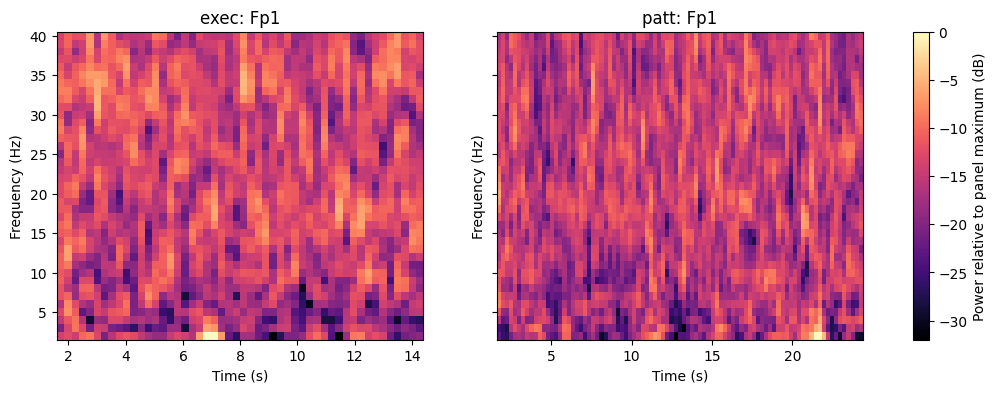

In [4]:
dataset_specs = {
    "exec": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Train",
        "dataset_step_type": "exec",
    },
    "patt": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Pattern",
        "dataset_step_type": "patt",
    },
}

rows = []
real_samples = {}
for family, spec in dataset_specs.items():
    dataset = SuperletDataset(**spec)
    started = perf_counter()
    sample = dataset[0]
    first_access_seconds = perf_counter() - started
    started = perf_counter()
    cached = dataset[0]
    cached_access_seconds = perf_counter() - started
    entry_dir = dataset.get_cache_entry_path(0)
    cache_bytes = sum(path.stat().st_size for path in entry_dir.iterdir() if path.is_file())

    assert sample.eeg_power.ndim == 3
    assert sample.eeg_power.shape[:2] == (63, 39)
    assert sample.times is not None
    assert np.allclose(np.diff(sample.times), 0.256)
    assert np.array_equal(cached.eeg_power, sample.eeg_power)
    assert np.array_equal(cached.times, sample.times)
    assert sample.eog.shape[0] == 5

    real_samples[family] = sample
    rows.append(
        {
            "family": family,
            "key": (
                sample.sample.subject_id,
                sample.sample.trial_number,
                sample.sample.block_index,
            ),
            "eeg_power_shape": sample.eeg_power.shape,
            "eog_shape": sample.eog.shape,
            "first_access_seconds": first_access_seconds,
            "cached_access_seconds": cached_access_seconds,
            "artifact_kib": cache_bytes / 1024.0,
        }
    )

real_summary = pd.DataFrame(rows).set_index("family")
display(real_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, (family, sample) in zip(axes, real_samples.items(), strict=True):
    channel_power = sample.eeg_power[0]
    relative_db = 10.0 * np.log10(np.maximum(channel_power, np.finfo(np.float32).tiny))
    relative_db -= relative_db.max()
    mesh = axis.pcolormesh(sample.times, sample.frequencies, relative_db, shading="auto", cmap="magma")
    axis.set(
        xlabel="Time (s)",
        ylabel="Frequency (Hz)",
        title=f"{family}: {sample.eeg_channels[0]}",
    )
fig.colorbar(mesh, ax=axes, label="Power relative to panel maximum (dB)")


## Conclusions

- The typed implementation reproduces the previous fractional adaptive Superlet coefficients to numerical precision while adding validation and explicit MIT provenance.
- Default edge trimming is 199 samples per side because the longest contributing fractional-order wavelet has 398 samples of support.
- The synthetic 20/24 Hz pair is resolved into separate local maxima with a lower 22 Hz midpoint.
- Real outputs obey `(channel, frequency, time)`, preserve original EOG separately, and round-trip through the versioned spectral cache.
- These native wavelet-power values remain unnormalized in artifacts; relative dB is used only for notebook display.
